OHLC Average Prediction of Apple Inc. Using LSTM Recurrent Neural Network

In [18]:
import os
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

os.environ["KERAS_BACKEND"] = "torch"
import keras

from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.layers import LSTM


In [3]:
import numpy as np


# FUNCTION TO CREATE 1D DATA INTO TIME SERIES DATASET
def new_dataset(dataset, step_size):
    data_X, data_Y = [], []
    for i in range(len(dataset) - step_size - 1):
        a = dataset[i : (i + step_size), 0]
        data_X.append(a)
        data_Y.append(dataset[i + step_size, 0])
    return np.array(data_X), np.array(data_Y)

In [5]:
# FOR REPRODUCIBILITY
np.random.seed(7)

# IMPORTING DATASET
dataset = pd.read_csv("../in/apple_share_price.csv", usecols=[1, 2, 3, 4])
dataset = dataset.reindex(index=dataset.index[::-1])
dataset.head()

# CREATING OWN INDEX FOR FLEXIBILITY
obs = np.arange(1, len(dataset) + 1, 1)

In [6]:
# TAKING DIFFERENT INDICATORS FOR PREDICTION
OHLC_avg = dataset.mean(axis=1)
HLC_avg = dataset[["High", "Low", "Close"]].mean(axis=1)
close_val = dataset[["Close"]]

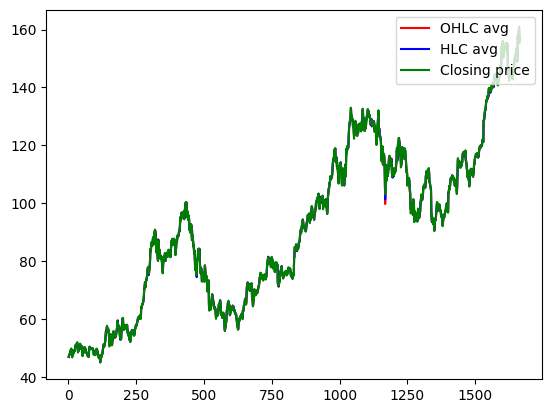

In [7]:
import matplotlib.pyplot as plt

# PLOTTING ALL INDICATORS IN ONE PLOT
plt.plot(obs, OHLC_avg, "r", label="OHLC avg")
plt.plot(obs, HLC_avg, "b", label="HLC avg")
plt.plot(obs, close_val, "g", label="Closing price")
plt.legend(loc="upper right")
plt.show()

In [8]:
# PREPARATION OF TIME SERIES DATASE
OHLC_avg = np.reshape(OHLC_avg.values, (len(OHLC_avg), 1))  # 1664
scaler = MinMaxScaler(feature_range=(0, 1))
OHLC_avg = scaler.fit_transform(OHLC_avg)
OHLC_avg

array([[0.01530745],
       [0.0196717 ],
       [0.02058364],
       ...,
       [1.        ],
       [0.97644172],
       [0.97398819]], shape=(1664, 1))

In [9]:
# TRAIN-TEST SPLIT
train_OHLC = int(len(OHLC_avg) * 0.75)
test_OHLC = len(OHLC_avg) - train_OHLC
train_OHLC, test_OHLC = (
    OHLC_avg[0:train_OHLC, :],
    OHLC_avg[train_OHLC : len(OHLC_avg), :],
)


In [10]:
# TIME-SERIES DATASET (FOR TIME T, VALUES FOR TIME T+1)
trainX, trainY = new_dataset(train_OHLC, 1)
testX, testY = new_dataset(test_OHLC, 1)

# RESHAPING TRAIN AND TEST DATA
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))
step_size = 1


In [12]:
# LSTM MODEL
model = Sequential()
model.add(LSTM(50, input_shape=(100, step_size), return_sequences=True))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.add(Activation("linear"))

# MODEL COMPILING AND TRAINING
model.compile(
    loss="mean_squared_error", optimizer="adam"
)  # Try SGD, adam, adagrad and compare!!!
model.fit(trainX, trainY, epochs=100, batch_size=64, verbose=0)

/workspaces/try-ml-stuff/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


 2/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Train RMSE: 1.22
Test RMSE: 1.62


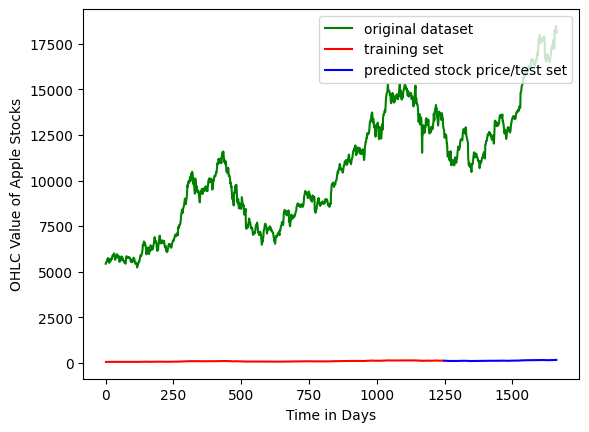

In [13]:
# PREDICTION
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

# DE-NORMALIZING FOR PLOTTING
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])


# TRAINING RMSE
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:, 0]))
print("Train RMSE: %.2f" % (trainScore))

# TEST RMSE
testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:, 0]))
print("Test RMSE: %.2f" % (testScore))

# CREATING SIMILAR DATASET TO PLOT TRAINING PREDICTIONS
trainPredictPlot = np.empty_like(OHLC_avg)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[step_size : len(trainPredict) + step_size, :] = trainPredict

# CREATING SIMILAR DATASSET TO PLOT TEST PREDICTIONS
testPredictPlot = np.empty_like(OHLC_avg)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict) + (step_size * 2) + 1 : len(OHLC_avg) - 1, :] = (
    testPredict
)

# DE-NORMALIZING MAIN DATASET
OHLC_avg = scaler.inverse_transform(OHLC_avg)

# DE-NORMALIZING MAIN DATASET
OHLC_avg = scaler.inverse_transform(OHLC_avg)

# PLOT OF MAIN OHLC VALUES, TRAIN PREDICTIONS AND TEST PREDICTIONS
plt.plot(OHLC_avg, "g", label="original dataset")
plt.plot(trainPredictPlot, "r", label="training set")
plt.plot(testPredictPlot, "b", label="predicted stock price/test set")
plt.legend(loc="upper right")
plt.xlabel("Time in Days")
plt.ylabel("OHLC Value of Apple Stocks")
plt.show()


In [15]:
# Calculate RMSE performance metrics
from sklearn.metrics import mean_squared_error

print(math.sqrt(mean_squared_error(trainY, trainPredict)))
print(math.sqrt(mean_squared_error(testY, testPredict)))

ValueError: Found input variables with inconsistent numbers of samples: [1, 1246]

In [16]:
# PREDICT FUTURE VALUES
last_val = testPredict[-1]
last_val_scaled = last_val / last_val
next_val = model.predict(np.reshape(last_val_scaled, (1, 1, 1)))
print("Last Day Value:", (last_val.item()))
print("Next Day Value:", (last_val * next_val).item())
# print np.append(last_val, next_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Last Day Value: 157.35693359375
Next Day Value: 153.5055694580078


In [17]:
# SAVE MODEL
model.save("build/release/ohlcv_forecast.keras")
# model.export(filepath="build/release/ohlcv_forecast")

FileNotFoundError: [Errno 2] No such file or directory: 'build/release/ohlcv_forecast.keras'